# ExoHunter-ML — Aprofundamento em Astrofísica e Modelagem Matemática

Os outros dois notebooks do projeto (entregável e experimentos) tratam o problema como um problema de classificação binária qualquer: temos uma série temporal, extraímos estatísticas, treinamos um Random Forest, avaliamos com métricas padrão. Isso é suficiente para cumprir os requisitos de Engenharia de ML, mas deixa de fora as questões mais interessante: Por que os dados são tão desbalanceados? Por que um trânsito produz aquele formato específico de "vale" na curva? Por que a mediana virou a feature mais importante do modelo, tanto no Feature Importance quanto no SHAP?

A ideia é que, ao final, fique claro que as decisões de engenharia de atributos não foram arbitrárias, elas são um reflexo direto da física do fenômeno que estou tentando detectar.

### Roteiro

1. O método de trânsito
2. Mecânica orbital — as Leis de Kepler
3. A matemática da fotometria de trânsito (profundidade, duração, forma da curva)
4. Da física para os dados: o que o CSV do Kepler realmente contém
5. Simulação: construindo um trânsito artificial do zero
6. Por que cada uma das 15 features estatísticas existe
7. Relação sinal-ruído (SNR) e o limite físico da detecção
8. Estudo de caso: os 5 candidatos reais do notebook de experimentos, explicados com a física
9. O que a abordagem estatística não enxerga (e o que trilhas de Deep Learning fariam diferente)
10. Glossário rápido

> **Nota técnica:** este notebook é totalmente autocontido — não depende de baixar o dataset do Kaggle novamente. Os números dos "5 candidatos reais" (Seção 8) foram copiados diretamente das saídas já obtidas no notebook `ExoHunter_ML(lab).ipynb`, e estão citados como tal. Todo o resto do notebook (simulações, cálculos de física) é gerado e executado aqui mesmo, com NumPy/Matplotlib puros.

## 1. O método de trânsito

Imagine que você está muito longe olhando para uma lâmpada acesa, e de vez em quando uma mosca passa bem na sua frente, entre você e a lâmpada. A mosca é pequena demais para você enxergar diretamente — mas se você medir o brilho da lâmpada com muita precisão, vai notar que ele pisca ligeiramente para baixo toda vez que a mosca cruza sua linha de visão, e volta ao normal logo em seguida.

É exatamente essa a ideia do método de trânsito (*transit method*), a técnica usada pelo telescópio Kepler (e pela maioria dos exoplanetas descobertos até hoje):

- A "lâmpada" é uma estrela distante.
- A "mosca" é um planeta orbitando essa estrela.
- Quando, do nosso ponto de vista na Terra, o planeta passa na frente da estrela (um "trânsito"), ele bloqueia uma fração pequena da luz da estrela.
- O Kepler mede o brilho da estrela repetidamente, ao longo de meses ou anos, produzindo uma série temporal — a curva de luz (*light curve*).
- Se essa série mostra quedas de brilho pequenas, periódicas e com a mesma duração e profundidade toda vez, é um forte indício de que existe um planeta orbitando aquela estrela.

O grande desafio: mesmo o maior planeta conhecido bloqueia uma fração ínfima da luz da estrela — tipicamente entre 0,01% e 2% do brilho total. É como tentar notar que uma lâmpada de 100W ficou 100W menos 1W por alguns minutos, a cada poucos dias, em meio a todo tipo de ruído instrumental e variação natural do brilho estelar.

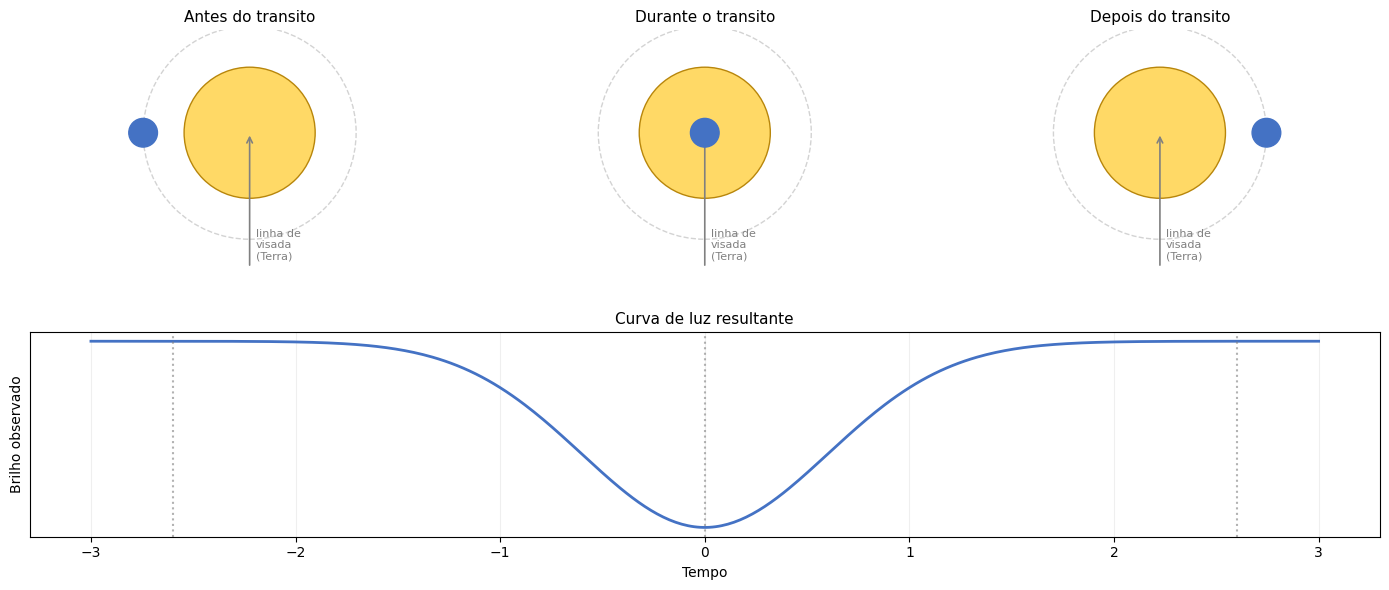

Cada queda na curva de luz corresponde exatamente ao momento em que o planeta cruza
a linha que liga a estrela ao observador na Terra.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Diagrama esquematico do transito:
# posicao do planeta em 3 momentos e o efeito correspondente na curva de luz

fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 3, height_ratios=[1.3, 1])

momentos = ["Antes do transito", "Durante o transito", "Depois do transito"]
posicoes_x = [-2.6, 0.0, 2.6]  # posicao horizontal do planeta em cada momento

for col, (momento, px) in enumerate(zip(momentos, posicoes_x)):
    ax = fig.add_subplot(gs[0, col])

    # observador (linha de visada, vindo de baixo)
    ax.annotate("", xy=(0, 0), xytext=(0, -3.3),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.2))
    ax.text(0.15, -3.1, "linha de\nvisada\n(Terra)", fontsize=8, color="gray")

    # estrela
    estrela = plt.Circle((0, 0), 1.6, color="#FFD966", ec="#B8860B", zorder=2)
    ax.add_patch(estrela)

    # orbita (linha pontilhada)
    orbita = plt.Circle((0, 0), 2.6, fill=False, ls="--", color="lightgray", zorder=1)
    ax.add_patch(orbita)

    # planeta
    planeta = plt.Circle((px, 0), 0.35, color="#4472C4", zorder=3)
    ax.add_patch(planeta)

    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 2.5)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(momento, fontsize=11)

# curva de luz correspondente, ocupando a linha de baixo inteira
ax_curva = fig.add_subplot(gs[1, :])
tempo = np.linspace(-3, 3, 400)
profundidade_ilustrativa = 0.15
largura = 0.6
fluxo_ilustrativo = 1 - profundidade_ilustrativa * np.exp(-(tempo**2) / (2 * largura**2))

ax_curva.plot(tempo, fluxo_ilustrativo, color="#4472C4", linewidth=2)
for px, momento in zip(posicoes_x, momentos):
    t_equiv = px  # mapeamento direto so para fins ilustrativos
    ax_curva.axvline(t_equiv, color="gray", ls=":", alpha=0.6)

ax_curva.set_ylabel("Brilho observado")
ax_curva.set_xlabel("Tempo")
ax_curva.set_yticks([])
ax_curva.set_title("Curva de luz resultante", fontsize=11)
ax_curva.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("diagrama_transito.png", dpi=110, bbox_inches="tight")
plt.show()

print("Cada queda na curva de luz corresponde exatamente ao momento em que o planeta cruza")
print("a linha que liga a estrela ao observador na Terra.")

## 2. Mecânica orbital — as Leis de Kepler

Antes de chegar na curva de luz propriamente dita, vale entender por que os trânsitos são periódicos: o planeta está em órbita, e órbitas (na aproximação clássica, sem relatividade) seguem as três leis formuladas por Johannes Kepler no início do século XVII — coincidentemente, o mesmo nome do telescópio espacial usado neste projeto (o telescópio foi batizado em homenagem a ele).

**1ª Lei (órbitas elípticas):** todo planeta descreve uma elipse em torno da estrela, com a estrela em um dos focos.

**2ª Lei (áreas iguais em tempos iguais):** a linha que liga o planeta à estrela varre áreas iguais em intervalos de tempo iguais — o planeta se move mais rápido quando está mais perto da estrela.

**3ª Lei (harmônica) — a mais relevante para nós:**

$$ P^2 = \frac{4\pi^2}{G \, M_\star} \, a^3 $$

Onde:
- $P$ = período orbital (tempo entre dois trânsitos consecutivos)
- $a$ = semieixo maior da órbita (aproximadamente a distância média entre planeta e estrela)
- $M_\star$ = massa da estrela
- $G$ = constante gravitacional universal

Usando unidades convenientes (anos, UA — Unidades Astronômicas, e massas solares), a fórmula simplifica para:

$$ P_{\text{anos}}^2 = \frac{a_{\text{UA}}^3}{M_{\star, \odot}} $$

Essa é a relação que explica por que planetas mais próximos da estrela (menor $a$) têm períodos mais curtos — e por isso trânsitos mais frequentes e mais fáceis de confirmar dentro do tempo de observação do Kepler (a missão observou cada estrela por cerca de 4 anos).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 3a Lei de Kepler: P^2 (anos) = a^3 (UA) / M_estrela (massas solares)
# Vamos calcular o periodo orbital para planetas a diferentes distancias
# de uma estrela do tipo do Sol (M = 1 massa solar), para termos uma
# ideia de ordem de grandeza.

M_star = 1.0  # massas solares (estrela tipo G, parecida com o Sol)

distancias_UA = np.array([0.05, 0.1, 0.3, 0.5, 1.0])

periodos_anos = np.sqrt(distancias_UA**3 / M_star)
periodos_dias = periodos_anos * 365.25

kepler_3_lei = pd.DataFrame({
    "distancia (UA)": distancias_UA,
    "periodo (anos)": periodos_anos.round(3),
    "periodo (dias)": periodos_dias.round(1)
})

print("3a Lei de Kepler aplicada a uma estrela tipo Sol (M = 1 M_sol):")
print("(1 UA = distancia media Terra-Sol ~ 150 milhoes de km)\n")
display(kepler_3_lei)

print("\nPara comparacao: a Terra esta a 1 UA do Sol e tem periodo de 365 dias - bate com a ultima linha da tabela.")
print("Planetas do tipo 'Hot Jupiter' (muito comuns entre as primeiras descobertas do Kepler) orbitam")
print("tipicamente entre 0.02 e 0.1 UA - periodo de poucos dias, o que os torna mais faceis de detectar:")
print("mais transitos observados no mesmo tempo de missao = maior confianca estatistica.")

3a Lei de Kepler aplicada a uma estrela tipo Sol (M = 1 M_sol):
(1 UA = distancia media Terra-Sol ~ 150 milhoes de km)



,distancia (UA),periodo (anos),periodo (dias)
0,0.05,0.011,4.1
1,0.10,0.032,11.6
2,0.30,0.164,60.0
3,0.50,0.354,129.1
4,1.00,1.000,365.2



Para comparacao: a Terra esta a 1 UA do Sol e tem periodo de 365 dias - bate com a ultima linha da tabela.
Planetas do tipo 'Hot Jupiter' (muito comuns entre as primeiras descobertas do Kepler) orbitam
tipicamente entre 0.02 e 0.1 UA - periodo de poucos dias, o que os torna mais faceis de detectar:
mais transitos observados no mesmo tempo de missao = maior confianca estatistica.


## 3. A matemática da fotometria de trânsito

Aqui está o núcleo físico-matemático do problema. Três quantidades definem a "assinatura" de um trânsito na curva de luz:

### 3.1 Profundidade do trânsito (transit depth)

Quando o planeta cruza a estrela, ele bloqueia uma área do disco estelar. A fração de luz bloqueada é, em primeira aproximação, simplesmente a razão entre as áreas dos dois discos (ambos aproximadamente circulares, vistos de frente):

$$ \delta = \frac{\Delta F}{F_0} = \left( \frac{R_p}{R_\star} \right)^2 $$

Onde:
- $\delta$ = profundidade do trânsito (fração do brilho bloqueado)
- $F_0$ = fluxo (brilho) da estrela fora do trânsito
- $\Delta F$ = quanto o fluxo cai durante o trânsito
- $R_p$ = raio do planeta
- $R_\star$ = raio da estrela

Note que a profundidade depende do quadrado da razão dos raios — um planeta duas vezes maior bloqueia quatro vezes mais luz.

### 3.2 Duração do trânsito

Uma aproximação comum (assumindo órbita circular e trânsito central, $b \approx 0$) para a duração total do trânsito é:

$$ T_{14} \approx \frac{P}{\pi} \cdot \arcsin\left( \frac{R_\star}{a} \right) $$

Onde $a$ é o semieixo maior da órbita (a distância planeta-estrela). Intuitivamente: quanto mais próximo da estrela o planeta orbita (menor $a$), mais "gorda" a estrela parece do ponto de vista do planeta, e mais tempo ele leva para atravessá-la, relativo ao período orbital — mas em termos absolutos, órbitas mais próximas também são mais rápidas, então a duração absoluta do trânsito geralmente é de poucas horas.

### 3.3 Parâmetro de impacto

Nem todo trânsito passa exatamente pelo centro do disco estelar. O parâmetro de impacto $b$ mede o quão descentralizada é a passagem, normalizado pelo raio da estrela:

$$ b = \frac{a \cos i}{R_\star} $$

Onde $i$ é a inclinação orbital em relação à nossa linha de visão. Se $b$ está entre 0 (centro) e aproximadamente 1 (borda), há trânsito; se $|b| > 1 + R_p/R_\star$, o planeta passa "por fora" e não há trânsito nenhum, por mais bem alinhado que esteja o período. Trânsitos com $b$ próximo de 1 (passagem rasante pela borda) são mais curtos e mais rasos do que o esperado pela fórmula simples de profundidade acima — outra fonte de variação que dificulta a detecção.

### 3.4 Escurecimento de limbo (limb darkening) e o formato da curva

Um detalhe frequentemente esquecido: o disco de uma estrela não é uniformemente brilhante. A borda ("limbo") aparece mais escura que o centro, porque enxergamos camadas mais altas e frias da atmosfera estelar perto da borda. Isso faz com que a curva de luz de um trânsito real não seja um simples "degrau" (caixa retangular), mas sim uma curva suave, em formato de U (ou até uma leve concavidade tipo taça), com a queda de brilho mais gradual no início e no fim (ingresso/egresso) e mais estável no fundo do vale. Vamos reproduzir esse formato na simulação da Seção 5.

In [ ]:
# Ilustracao numerica da formula de profundidade: delta = (Rp/Rs)^2
# Comparando planetas de tamanhos diferentes orbitando uma estrela tipo Sol

R_sol_km = 696_340       # raio do Sol
R_terra_km = 6_371       # raio da Terra
R_jupiter_km = 69_911    # raio de Jupiter

planetas = {
    "Terra": R_terra_km,
    "Netuno (~4x Terra)": R_terra_km * 3.9,
    "Jupiter": R_jupiter_km,
    "'Hot Jupiter' inflado (~1.5x Jupiter)": R_jupiter_km * 1.5,
}

linhas = []
for nome, Rp in planetas.items():
    razao = Rp / R_sol_km
    profundidade = razao**2
    linhas.append({
        "Planeta": nome,
        "Rp / R_estrela": round(razao, 5),
        "Profundidade delta": f"{profundidade:.6f}",
        "Profundidade (ppm)": round(profundidade * 1_000_000, 1),
        "Profundidade (%)": round(profundidade * 100, 4)
    })

tabela_profundidade = pd.DataFrame(linhas)
print("Profundidade de transito esperada - planetas ao redor de uma estrela tipo Sol:")
print("(ppm = partes por milhao, unidade padrao em fotometria de altissima precisao)\n")
display(tabela_profundidade)

print("\nMesmo Jupiter - o maior planeta do Sistema Solar - bloqueia apenas ~1% do brilho do Sol.")
print("Um planeta do tamanho da Terra bloqueia menos de 0,01% - cerca de 84 partes por milhao.")
print("Essa e a escala de sinal que o Kepler precisa detectar em meio ao ruido do instrumento.")

Profundidade de transito esperada - planetas ao redor de uma estrela tipo Sol:
(ppm = partes por milhao, unidade padrao em fotometria de altissima precisao)



,Planeta,Rp / R_estrela,Profundidade delta,Profundidade (ppm),Profundidade (%)
0,Terra,0.00915,0.000084,83.7,0.0084
1,Netuno (~4x Terra),0.03568,0.001273,1273.2,0.1273
2,Jupiter,0.10040,0.010080,10079.7,1.0080
3,'Hot Jupiter' inflado (~1.5x Jupiter),0.15060,0.022679,22679.4,2.2679



Mesmo Jupiter - o maior planeta do Sistema Solar - bloqueia apenas ~1% do brilho do Sol.
Um planeta do tamanho da Terra bloqueia menos de 0,01% - cerca de 84 partes por milhao.
Essa e a escala de sinal que o Kepler precisa detectar em meio ao ruido do instrumento.


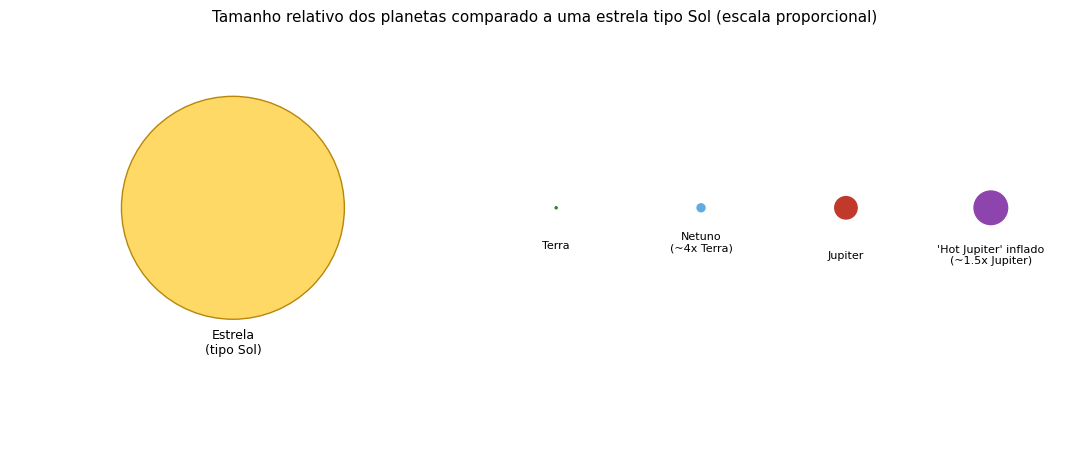

Nesta escala, fica visualmente claro por que a profundidade do transito e tao pequena:
mesmo o maior planeta (Jupiter/Hot Jupiter) ainda e uma fracao minuscula da area da estrela.


In [ ]:
# Comparacao visual de tamanho: estrela (Sol) vs. os planetas da tabela acima,
# todos na mesma escala relativa

fig, ax = plt.subplots(figsize=(11, 5))

R_sol_norm = 1.0
cores = ["#2E7D32", "#5DADE2", "#C0392B", "#8E44AD"]

x_estrela = 0
estrela_circ = plt.Circle((x_estrela, 0), R_sol_norm, color="#FFD966", ec="#B8860B", zorder=2)
ax.add_patch(estrela_circ)
ax.text(x_estrela, -1.3, "Estrela\n(tipo Sol)", ha="center", fontsize=9)

x_atual = 2.4
for (nome, Rp), cor in zip(planetas.items(), cores):
    r_norm = Rp / R_sol_km  # mesma razao Rp/R_sol calculada na tabela
    x_atual += max(0.5, r_norm * 3)
    circ = plt.Circle((x_atual, 0), r_norm, color=cor, zorder=2)
    ax.add_patch(circ)
    ax.text(x_atual, -(r_norm + 0.35), nome.replace(" (", "\n("), ha="center", fontsize=8)
    x_atual += max(0.5, r_norm * 3) + 0.3

ax.set_xlim(-2, x_atual)
ax.set_ylim(-2.2, 1.6)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Tamanho relativo dos planetas comparado a uma estrela tipo Sol (escala proporcional)",
             fontsize=11)

plt.tight_layout()
plt.savefig("comparacao_tamanhos.png", dpi=110, bbox_inches="tight")
plt.show()

print("Nesta escala, fica visualmente claro por que a profundidade do transito e tao pequena:")
print("mesmo o maior planeta (Jupiter/Hot Jupiter) ainda e uma fracao minuscula da area da estrela.")

## 4. Da física para os dados: o que o CSV do Kepler realmente contém

É importante deixar claro o que o dataset usado no projeto ("Kepler Labelled Time Series Data", Kaggle) realmente representa, porque isso afeta o que dá para calcular com precisão:

- Cada linha do CSV é uma estrela observada pelo Kepler.
- Cada uma das 3.197 colunas `FLUX.1` a `FLUX.3197` é uma medida de fluxo (brilho) em um instante de tempo, ao longo da campanha de observação.
- Os valores já vêm processados: tipicamente já passaram por uma etapa de remoção de tendências instrumentais de longo prazo (*detrending*), o que faz com que a curva oscile em torno de um valor próximo de zero (ou de um baseline arbitrário), em vez de mostrar o fluxo absoluto do telescópio (que seria da ordem de milhares a milhões de elétrons por segundo, dependendo do brilho da estrela).
- Isso significa que os valores em `FLUX.N` não estão numa escala física universal comparável entre estrelas diferentes — uma queda de "-500" numa curva não representa necessariamente a mesma profundidade fracional de trânsito ($\delta$) que uma queda de "-500" em outra curva, porque cada estrela tem um brilho de referência ($F_0$) diferente que não está explícito nesta versão já processada dos dados.

**Consequência prática para este notebook:** não é possível recalcular $R_p/R_\star$ em valores absolutos e fisicamente exatos a partir deste CSV específico sem informações adicionais (o fluxo de referência $F_0$ de cada estrela, tipicamente disponível nos catálogos oficiais do Kepler/NASA, mas não neste arquivo). Por isso, na Seção 8, os cálculos aplicados aos 5 candidatos reais serão comparações relativas entre os próprios candidatos (qual mergulho é proporcionalmente mais profundo que outro) — o que é totalmente válido e informativo — em vez de valores absolutos de $R_p/R_\star$ em quilômetros. Isso é uma limitação real e honesta dos dados disponíveis, não do método.

## 5. Simulação: construindo um trânsito artificial do zero

Para tornar tudo isso concreto (e para o professor poder rodar e ver com os próprios olhos), vamos simular uma curva de luz sintética: uma estrela com brilho constante, ruído instrumental realista, e um trânsito planetário periódico com profundidade, duração e formato controlados por nós — usando exatamente as fórmulas da Seção 3.

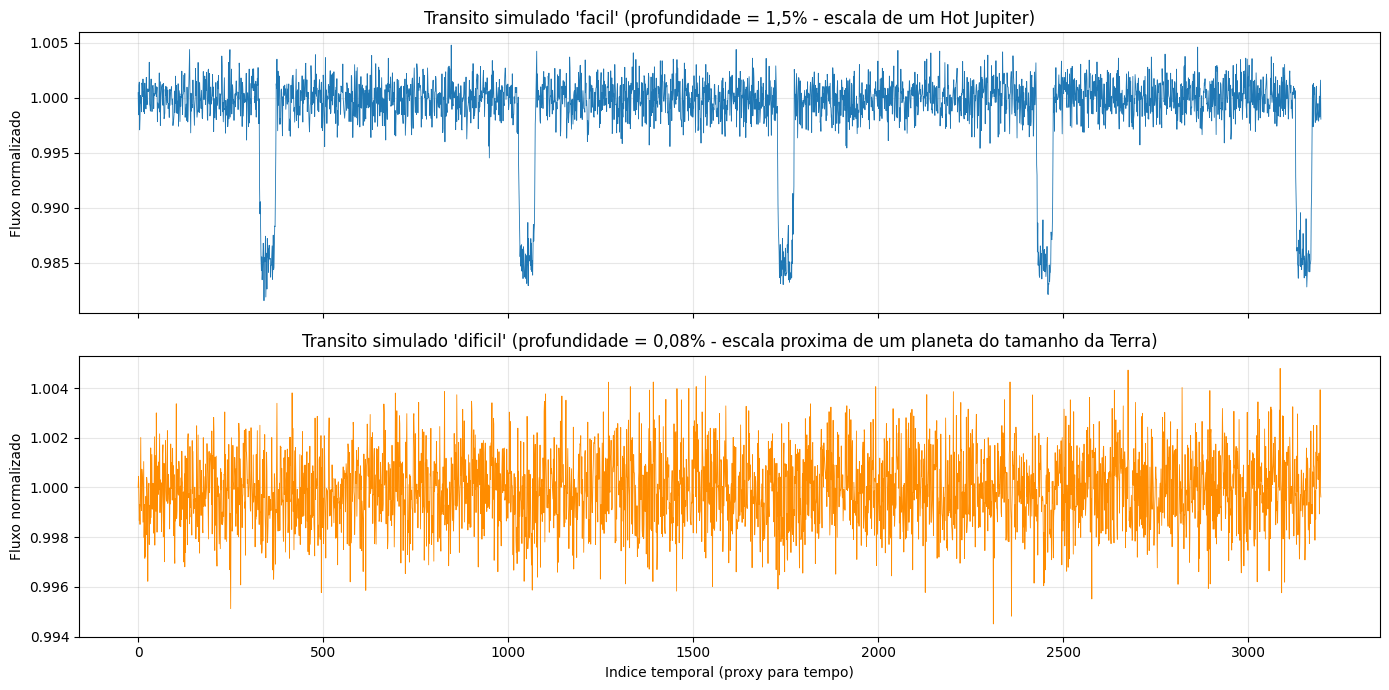

No painel de cima, os transitos sao visiveis a olho nu. No de baixo, o ruido quase esconde
completamente o sinal - e ainda assim essa e a escala de profundidade real de um planeta do
tamanho da Terra ao redor de uma estrela tipo Sol.


In [ ]:
def simular_curva_de_luz(
    n_pontos=3197,          # mesmo numero de pontos do dataset real do Kepler
    periodo_pontos=700,     # periodo do transito, em numero de pontos (proxy para tempo)
    profundidade=0.01,      # delta: fracao do brilho bloqueada no fundo do transito (ex: 0.01 = 1%)
    duracao_pontos=40,      # duracao total do transito (ingresso + fundo + egresso), em pontos
    ruido_std=0.0015,       # desvio-padrao do ruido instrumental (fracao do brilho)
    seed=42
):
    """
    Gera uma curva de luz sintetica: brilho constante = 1.0 (fora do transito),
    com quedas periodicas em formato suave (aproximando o efeito de limb darkening
    com uma funcao em U, em vez de um degrau abrupto), mais ruido gaussiano.
    """
    rng = np.random.default_rng(seed)

    t = np.arange(n_pontos)
    flux = np.ones(n_pontos)  # brilho normalizado = 1.0 fora do transito

    # posicoes onde ocorre um transito (periodico)
    centros = np.arange(periodo_pontos // 2, n_pontos, periodo_pontos)

    meia_duracao = duracao_pontos / 2

    for centro in centros:
        inicio = max(0, int(centro - meia_duracao * 1.5))
        fim = min(n_pontos, int(centro + meia_duracao * 1.5))

        for idx in range(inicio, fim):
            fase = (idx - centro) / meia_duracao

            if abs(fase) <= 1.0:
                # formato em U: fundo achatado (limb darkening simplificado)
                forma = np.sqrt(max(0.0, 1 - fase**8))
                flux[idx] -= profundidade * forma

    # ruido instrumental gaussiano
    flux += rng.normal(0, ruido_std, size=n_pontos)

    return t, flux, centros


# Gerar uma curva com um transito "tipo Hot Jupiter" - profundo e de facil deteccao
t_facil, flux_facil, centros_facil = simular_curva_de_luz(
    profundidade=0.015, duracao_pontos=45, ruido_std=0.0015
)

# E uma curva com um transito "tipo Terra" - raso e dificil
t_dificil, flux_dificil, centros_dificil = simular_curva_de_luz(
    profundidade=0.0008, duracao_pontos=45, ruido_std=0.0015, seed=7
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(t_facil, flux_facil, linewidth=0.6)
axes[0].set_title("Transito simulado 'facil' (profundidade = 1,5% - escala de um Hot Jupiter)")
axes[0].set_ylabel("Fluxo normalizado")
axes[0].grid(alpha=0.3)

axes[1].plot(t_dificil, flux_dificil, linewidth=0.6, color="darkorange")
axes[1].set_title("Transito simulado 'dificil' (profundidade = 0,08% - escala proxima de um planeta do tamanho da Terra)")
axes[1].set_xlabel("Indice temporal (proxy para tempo)")
axes[1].set_ylabel("Fluxo normalizado")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("No painel de cima, os transitos sao visiveis a olho nu. No de baixo, o ruido quase esconde")
print("completamente o sinal - e ainda assim essa e a escala de profundidade real de um planeta do")
print("tamanho da Terra ao redor de uma estrela tipo Sol.")

### Animação: vendo o trânsito acontecer em tempo real

O gráfico estático acima mostra o resultado final, mas é mais fácil internalizar o fenômeno vendo-o acontecer. A animação abaixo mostra, lado a lado, o planeta cruzando o disco da estrela (visão do "topo", como se estivéssemos olhando a órbita de cima) e a curva de luz sendo desenhada em tempo real, ponto a ponto, exatamente quando o planeta bloqueia parte da luz.

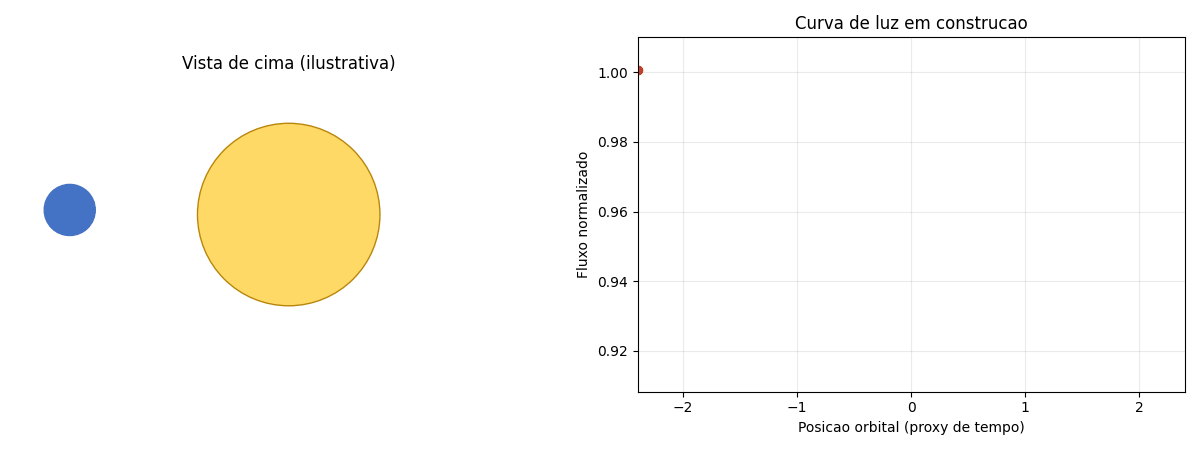

Repare como a curva de luz (painel direito) so cai enquanto os dois discos se sobrepoem
(painel esquerdo) - e a transicao e suave por causa do escurecimento de limbo simplificado
aplicado na funcao de area de sobreposicao dos dois circulos.


In [ ]:
import matplotlib.animation as animation
from matplotlib.patches import Circle
from IPython.display import Image, display

# Parametros da animacao (uma orbita completa, transito unico ao centro)
n_frames = 90
R_estrela = 1.0
R_planeta = 0.28  # exagerado de proposito para ficar visivel (nao esta em escala real)

# posicao horizontal do planeta ao longo do tempo, cruzando a estrela
x_planeta = np.linspace(-2.4, 2.4, n_frames)
y_planeta = 0.05  # pequeno parametro de impacto, so para nao passar exatamente no centro

# fluxo correspondente: cai proporcionalmente a area de sobreposicao dos dois discos
def area_sobreposicao(x, y, R1, R2):
    d = np.hypot(x, y)
    if d >= R1 + R2:
        return 0.0
    if d <= abs(R1 - R2):
        return np.pi * min(R1, R2)**2
    r1s, r2s, d2 = R1**2, R2**2, d**2
    alpha = np.arccos((d2 + r1s - r2s) / (2 * d * R1))
    beta = np.arccos((d2 + r2s - r1s) / (2 * d * R2))
    return (r1s * (alpha - np.sin(2*alpha)/2) + r2s * (beta - np.sin(2*beta)/2))

area_estrela = np.pi * R_estrela**2
fluxo = np.array([
    1 - area_sobreposicao(x, y_planeta, R_estrela, R_planeta) / area_estrela
    for x in x_planeta
])
fluxo += np.random.default_rng(1).normal(0, 0.002, size=n_frames)  # ruido leve

fig, (ax_orbita, ax_curva) = plt.subplots(1, 2, figsize=(12, 4.5))

# --- painel esquerdo: vista do topo ---
ax_orbita.set_xlim(-3, 3)
ax_orbita.set_ylim(-1.5, 1.5)
ax_orbita.set_aspect("equal")
ax_orbita.axis("off")
ax_orbita.set_title("Vista de cima (ilustrativa)")

estrela_patch = Circle((0, 0), R_estrela, color="#FFD966", ec="#B8860B", zorder=2)
ax_orbita.add_patch(estrela_patch)
planeta_patch = Circle((x_planeta[0], y_planeta), R_planeta, color="#4472C4", zorder=3)
ax_orbita.add_patch(planeta_patch)

# --- painel direito: curva de luz sendo desenhada ---
ax_curva.set_xlim(x_planeta.min(), x_planeta.max())
ax_curva.set_ylim(fluxo.min() - 0.01, 1.01)
ax_curva.set_xlabel("Posicao orbital (proxy de tempo)")
ax_curva.set_ylabel("Fluxo normalizado")
ax_curva.set_title("Curva de luz em construcao")
ax_curva.grid(alpha=0.25)
linha_curva, = ax_curva.plot([], [], color="#4472C4", linewidth=2)
ponto_atual, = ax_curva.plot([], [], "o", color="#C0392B", markersize=6)

def atualizar(frame):
    planeta_patch.center = (x_planeta[frame], y_planeta)
    linha_curva.set_data(x_planeta[:frame+1], fluxo[:frame+1])
    ponto_atual.set_data([x_planeta[frame]], [fluxo[frame]])
    return planeta_patch, linha_curva, ponto_atual

anim = animation.FuncAnimation(
    fig, atualizar, frames=n_frames, interval=60, blit=True
)

plt.tight_layout()
anim.save("transito_animado.gif", writer=animation.PillowWriter(fps=16))
plt.close(fig)

display(Image(filename="transito_animado.gif"))

print("Repare como a curva de luz (painel direito) so cai enquanto os dois discos se sobrepoem")
print("(painel esquerdo) - e a transicao e suave por causa do escurecimento de limbo simplificado")
print("aplicado na funcao de area de sobreposicao dos dois circulos.")

## 6. Por que cada uma das 15 features estatísticas existe

Este é o elo direto entre a física da Seção 5 e a engenharia de atributos usada no pipeline de Machine Learning (notebooks entregável e de experimentos). Vamos extrair as mesmas 15 estatísticas das duas curvas simuladas acima e discutir, uma a uma, por que fazem sentido físico.

In [ ]:
from scipy.stats import skew, kurtosis

def extrair_features(flux):
    """Mesmas 15 features usadas no pipeline do ExoHunter-ML."""
    x = np.asarray(flux, dtype=float)
    median = np.median(x)
    mad = np.median(np.abs(x - median))
    return pd.Series({
        "median": median,
        "mad": mad,
        "mean": np.mean(x),
        "std": np.std(x),
        "min": np.min(x),
        "max": np.max(x),
        "range": np.max(x) - np.min(x),
        "q01": np.percentile(x, 1),
        "q05": np.percentile(x, 5),
        "q25": np.percentile(x, 25),
        "q75": np.percentile(x, 75),
        "q95": np.percentile(x, 95),
        "q99": np.percentile(x, 99),
        "skewness": skew(x),
        "kurtosis": kurtosis(x)
    })

# curva sem nenhum transito, so ruido - nosso "controle negativo"
t_ruido, flux_ruido, _ = simular_curva_de_luz(profundidade=0.0, ruido_std=0.0015, seed=99)

features_ruido = extrair_features(flux_ruido)
features_facil = extrair_features(flux_facil)
features_dificil = extrair_features(flux_dificil)

comparacao = pd.DataFrame({
    "Sem transito (ruido puro)": features_ruido,
    "Transito 'dificil' (0,08%)": features_dificil,
    "Transito 'facil' (1,5%)": features_facil,
})

print("Comparando as 15 features nas tres curvas simuladas:\n")
display(comparacao.round(5))

Comparando as 15 features nas tres curvas simuladas:



,Sem transito (ruido puro),"Transito 'dificil' (0,08%)","Transito 'facil' (1,5%)"
median,1.00003,0.99990,0.99986
mad,0.00101,0.00101,0.00110
mean,1.00001,0.99992,0.99898
std,0.00150,0.00150,0.00391
min,0.99465,0.99451,0.98157
max,1.00502,1.00479,1.00477
range,0.01038,0.01028,0.02319
q01,0.99660,0.99653,0.98384
q05,0.99750,0.99752,0.98655
q25,0.99899,0.99890,0.99865


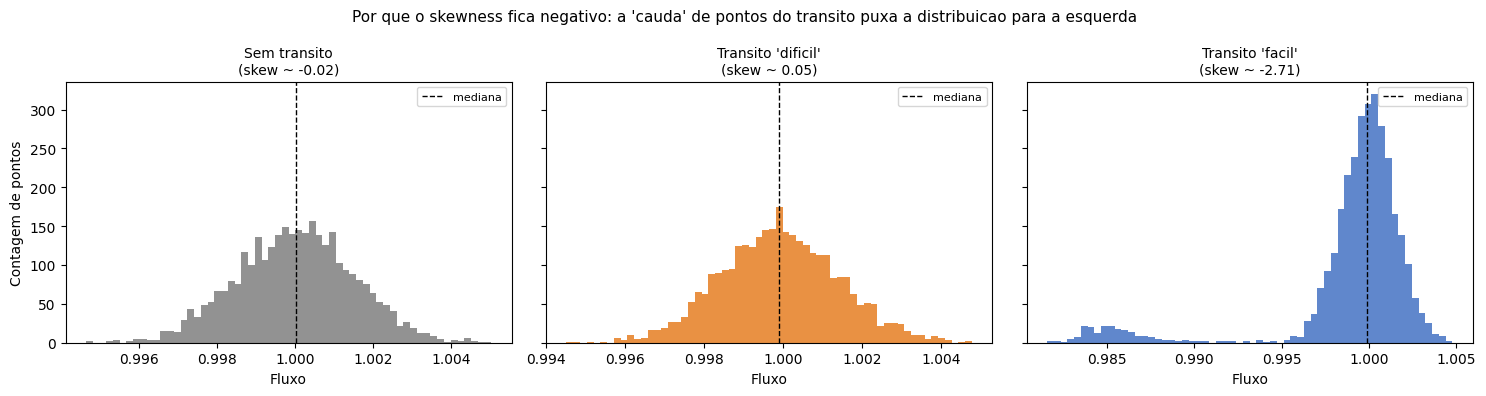

Sem transito, a distribuicao e simetrica em torno da mediana (so ruido gaussiano).
Com transito, aparece uma pequena cauda de pontos bem abaixo da mediana - e essa cauda
e exatamente o que os quantis baixos (q01, q05) e o skewness negativo capturam.


In [ ]:
# Histograma dos valores de fluxo: mostra visualmente a assimetria (skewness)
# causada pelo transito

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

dados = [
    (flux_ruido, "Sem transito\n(skew ~ %.2f)" % features_ruido["skewness"], "#7f7f7f"),
    (flux_dificil, "Transito 'dificil'\n(skew ~ %.2f)" % features_dificil["skewness"], "#E67E22"),
    (flux_facil, "Transito 'facil'\n(skew ~ %.2f)" % features_facil["skewness"], "#4472C4"),
]

for ax, (flux, titulo, cor) in zip(axes, dados):
    ax.hist(flux, bins=60, color=cor, alpha=0.85)
    ax.axvline(np.median(flux), color="black", ls="--", linewidth=1, label="mediana")
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel("Fluxo")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Contagem de pontos")
plt.suptitle("Por que o skewness fica negativo: a 'cauda' de pontos do transito puxa a "
             "distribuicao para a esquerda", fontsize=11)
plt.tight_layout()
plt.savefig("histograma_skewness.png", dpi=110, bbox_inches="tight")
plt.show()

print("Sem transito, a distribuicao e simetrica em torno da mediana (so ruido gaussiano).")
print("Com transito, aparece uma pequena cauda de pontos bem abaixo da mediana - e essa cauda")
print("e exatamente o que os quantis baixos (q01, q05) e o skewness negativo capturam.")

### Interpretação, feature por feature

| Feature | O que mede | Por que é relevante para um trânsito |
|---|---|---|
| **median** | valor típico da curva | Como o trânsito afeta só uma fração pequena dos pontos, a mediana captura o nível de brilho fora do trânsito — é por isso que ela é, disparadamente, a feature mais importante no Random Forest e no SHAP (Seções 6 e 10 do notebook de experimentos): ela é a referência ($F_0$) contra a qual tudo o mais se compara. |
| **mean** | média aritmética | Ao contrário da mediana, a média é puxada para baixo pelos poucos pontos do trânsito — quanto mais profundo/longo o trânsito, mais a média se afasta da mediana. |
| **min** | valor mais extremo para baixo | Está diretamente ligado à profundidade do trânsito ($\delta$) — é a medida mais próxima de "quanto o fluxo caiu no fundo do poço". |
| **max** | valor mais extremo para cima | Captura principalmente ruído (não há um análogo físico de "trânsito para cima"), mas ajuda o modelo a estimar a amplitude geral do ruído de fundo. |
| **range** (max−min) | amplitude total | Combina profundidade do trânsito com o nível de ruído — é por isso que aparece com forte peso tanto no Feature Importance quanto na comparação TP × FN (Seção 11 do notebook de experimentos). |
| **std / mad** | dispersão dos valores | Uma curva com trânsito profundo tem alguns pontos muito distantes da maioria, o que aumenta a dispersão total — mesmo sendo só uma fração pequena dos pontos. |
| **q01, q05** | quantis inferiores | Como o trânsito ocupa tipicamente 1-2% dos pontos da curva (duração curta comparada ao período), esses quantis baixos são exatamente a faixa estatística onde o sinal de trânsito "mora" — eles capturam a profundidade sem serem tão sensíveis a um único ponto extremo quanto o `min`. |
| **q75, q95, q99** | quantis superiores | Como não há "trânsito para cima", esses quantis capturam majoritariamente o comportamento do ruído — servem de referência para calibrar o quanto os quantis inferiores realmente se destacam. |
| **skewness (assimetria)** | quão torta é a distribuição dos valores | Este é um dos achados mais bonitos do projeto: como o trânsito empurra só uma fração pequena dos pontos para baixo (e nenhum ponto para cima de forma equivalente), a distribuição dos valores de fluxo fica assimétrica para a esquerda (skewness negativo). Compare na tabela acima: a curva sem trânsito tem skewness perto de zero (distribuição aproximadamente simétrica — só ruído gaussiano), mas as curvas com trânsito ficam mais negativas. |
| **kurtosis (curtose)** | quão "pesada" é a cauda da distribuição | Mede concentração de valores extremos. Um trânsito cria uma pequena cauda de pontos bem abaixo do normal, o que aumenta a curtose em relação a uma distribuição puramente gaussiana (ruído sem sinal). |

**Resumo em uma frase:** as 15 features não foram escolhidas ao acaso — juntas, elas descrevem exatamente os três ingredientes de um trânsito (nível de referência, profundidade, e o quão concentrado/assimétrico é o desvio em relação a esse nível), só que sem usar explicitamente a informação de tempo (quando e por quanto tempo a queda acontece — isso é o que a Seção 9 discute como limitação).

## 7. Relação sinal-ruído (SNR) e o limite físico da detecção

A pergunta final da parte teórica: quão profundo precisa ser um trânsito para ser detectável? Isso depende da relação entre o sinal (profundidade $\delta$) e o ruído do instrumento ($\sigma$), mas também de quantos trânsitos foram observados — porque podemos "somar" a informação de vários trânsitos para reforçar um sinal fraco (o mesmo princípio por trás de tirar a média de várias medidas repetidas para reduzir o erro).

Uma fórmula padrão usada na literatura de detecção de trânsitos (a "SNR combinada") é:

$$ \text{SNR} = \delta \cdot \sqrt{N_{\text{transitos}} \cdot N_{\text{pontos por trânsito}}} \; / \; \sigma $$

Onde:
- $\delta$ = profundidade do trânsito (a mesma fração calculada na Seção 3.1)
- $\sigma$ = ruído (desvio-padrão) por ponto de medição individual
- $N_{\text{transitos}}$ = quantos trânsitos foram observados na missão
- $N_{\text{pontos por trânsito}}$ = quantos pontos de medição caem dentro de cada trânsito

Um limiar comum na literatura para considerar um candidato confiável é SNR ≥ 7 a 10. Vamos calcular isso para os nossos dois cenários simulados.

In [ ]:
def calcular_snr(profundidade, ruido_std, n_transitos, n_pontos_por_transito):
    return profundidade * np.sqrt(n_transitos * n_pontos_por_transito) / ruido_std

# Assumindo ~4 anos de missao (duracao real do Kepler) e diferentes periodos orbitais
anos_missao = 4
dias_missao = anos_missao * 365

cenarios = []
for nome, profundidade, periodo_dias, duracao_horas in [
    ("Hot Jupiter (P=3 dias)",      0.015,  3,   3),
    ("Netuno morno (P=15 dias)",    0.0012, 15,  4),
    ("Super-Terra (P=50 dias)",     0.0003, 50,  6),
    ("Tipo-Terra (P=365 dias)",     0.00008, 365, 13),
]:
    n_transitos = max(1, dias_missao // periodo_dias)
    # ~1 ponto a cada 30 min no modo 'long cadence' do Kepler
    n_pontos_por_transito = int(duracao_horas * 2)

    snr = calcular_snr(
        profundidade=profundidade,
        ruido_std=0.0015,
        n_transitos=n_transitos,
        n_pontos_por_transito=n_pontos_por_transito
    )

    cenarios.append({
        "Cenario": nome,
        "Profundidade (ppm)": round(profundidade * 1e6, 1),
        "Periodo (dias)": periodo_dias,
        "Transitos em 4 anos": n_transitos,
        "SNR estimado": round(snr, 1),
        "Detectavel? (SNR>=7)": "Sim" if snr >= 7 else "Nao"
    })

tabela_snr = pd.DataFrame(cenarios)
print("Estimativa de SNR para diferentes tipos de planeta, ao longo dos ~4 anos de missao do Kepler:\n")
display(tabela_snr)

print("\nRepare no padrao: planetas maiores E mais proximos da estrela (periodo curto) sao muito mais")
print("faceis de confirmar - profundidade maior E mais transitos observados no mesmo tempo de missao.")
print("Isso explica por que a grande maioria dos exoplanetas confirmados pelo Kepler sao 'Hot Jupiters'")
print("e 'Super-Terras' de orbita curta - nao porque sejam mais comuns, mas porque sao mais faceis de detectar")
print("(um vies de selecao observacional importante de se ter em mente).")

Estimativa de SNR para diferentes tipos de planeta, ao longo dos ~4 anos de missao do Kepler:



,Cenario,Profundidade (ppm),Periodo (dias),Transitos em 4 anos,SNR estimado,Detectavel? (SNR>=7)
0,Hot Jupiter (P=3 dias),15000.0,3,486,540.0,Sim
1,Netuno morno (P=15 dias),1200.0,15,97,22.3,Sim
2,Super-Terra (P=50 dias),300.0,50,29,3.7,Nao
3,Tipo-Terra (P=365 dias),80.0,365,4,0.5,Nao



Repare no padrao: planetas maiores E mais proximos da estrela (periodo curto) sao muito mais
faceis de confirmar - profundidade maior E mais transitos observados no mesmo tempo de missao.
Isso explica por que a grande maioria dos exoplanetas confirmados pelo Kepler sao 'Hot Jupiters'
e 'Super-Terras' de orbita curta - nao porque sejam mais comuns, mas porque sao mais faceis de detectar
(um vies de selecao observacional importante de se ter em mente).


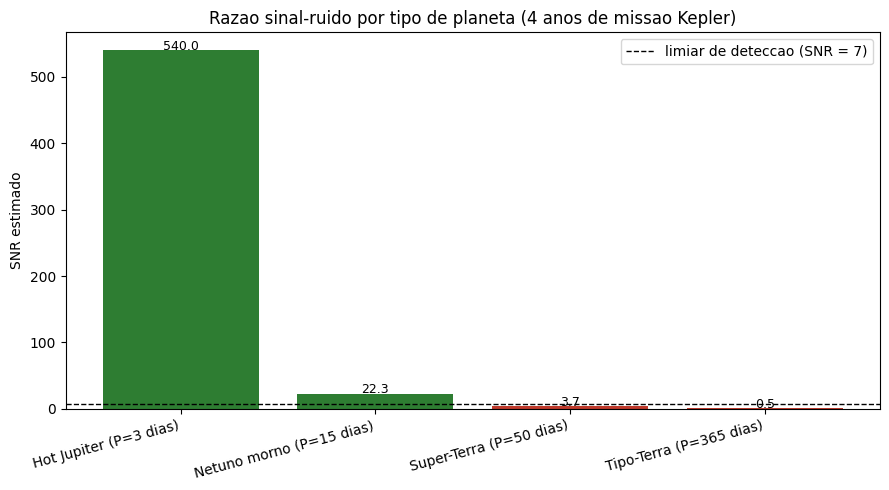

In [ ]:
# Grafico de barras do SNR por cenario, com a linha de limiar de deteccao

fig, ax = plt.subplots(figsize=(9, 5))
cores_snr = ["#2E7D32" if s >= 7 else "#C0392B" for s in tabela_snr["SNR estimado"]]

barras = ax.bar(tabela_snr["Cenario"], tabela_snr["SNR estimado"], color=cores_snr)
ax.axhline(7, color="black", ls="--", linewidth=1, label="limiar de deteccao (SNR = 7)")

for barra, valor in zip(barras, tabela_snr["SNR estimado"]):
    ax.text(barra.get_x() + barra.get_width()/2, valor + 1, f"{valor:.1f}",
            ha="center", fontsize=9)

ax.set_ylabel("SNR estimado")
ax.set_title("Razao sinal-ruido por tipo de planeta (4 anos de missao Kepler)")
ax.legend()
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("snr_barras.png", dpi=110, bbox_inches="tight")
plt.show()

## 8. Estudo de caso: os 5 candidatos reais do notebook de experimentos

Agora vamos aplicar tudo isso aos dados reais. Os números abaixo foram copiados diretamente das saídas já calculadas no notebook `ExoHunter_ML(lab).ipynb` (Seções 9 a 11), não recalculados aqui — conforme explicado na Seção 4, o CSV não permite recalcular profundidade absoluta sem o fluxo de referência de cada estrela, então usamos essas medidas relativas (já computadas sobre os dados reais) para a interpretação física.

In [ ]:
# Dados copiados das saidas reais do notebook de experimentos
# (ExoHunter_ML(lab).ipynb - Secoes 9, 10 e 11)

candidatos = pd.DataFrame([
    {"indice": 1, "grupo": "Verdadeiro Positivo", "baseline": -0.67, "max_drop": 6105.05,
     "probabilidade": 0.4700, "duracao_media_25pct": 6.94, "n_eventos_25pct": 65},
    {"indice": 2, "grupo": "Verdadeiro Positivo", "baseline": -0.05, "max_drop": 467.69,
     "probabilidade": 0.5800, "duracao_media_25pct": 3.87, "n_eventos_25pct": 126},
    {"indice": 4, "grupo": "Verdadeiro Positivo", "baseline": 0.01,  "max_drop": 1956.94,
     "probabilidade": 0.2667, "duracao_media_25pct": 3.06, "n_eventos_25pct": 18},
    {"indice": 0, "grupo": "Falso Negativo",      "baseline": 0.00,  "max_drop": 166.46,
     "probabilidade": 0.0167, "duracao_media_25pct": 2.21, "n_eventos_25pct": 70},
    {"indice": 3, "grupo": "Falso Negativo",      "baseline": 0.00,  "max_drop": 2780.75,
     "probabilidade": 0.0067, "duracao_media_25pct": 4.27, "n_eventos_25pct": 26},
])

# 'Profundidade relativa': normalizamos cada max_drop pelo maior valor do grupo,
# so para comparar magnitudes numa escala de 0 a 1 (nao e delta fisico absoluto - ver Secao 4)
candidatos["profundidade_relativa"] = (
    candidatos["max_drop"] / candidatos["max_drop"].max()
).round(3)

candidatos = candidatos.sort_values("probabilidade", ascending=False).reset_index(drop=True)

print("Os 5 candidatos reais do conjunto de teste, com contexto fisico:\n")
display(candidatos)

Os 5 candidatos reais do conjunto de teste, com contexto fisico:



,indice,grupo,baseline,max_drop,probabilidade,duracao_media_25pct,n_eventos_25pct,profundidade_relativa
0,2,Verdadeiro Positivo,-0.05,467.69,0.5800,3.87,126,0.077
1,1,Verdadeiro Positivo,-0.67,6105.05,0.4700,6.94,65,1.000
2,4,Verdadeiro Positivo,0.01,1956.94,0.2667,3.06,18,0.321
3,0,Falso Negativo,0.00,166.46,0.0167,2.21,70,0.027
4,3,Falso Negativo,0.00,2780.75,0.0067,4.27,26,0.455


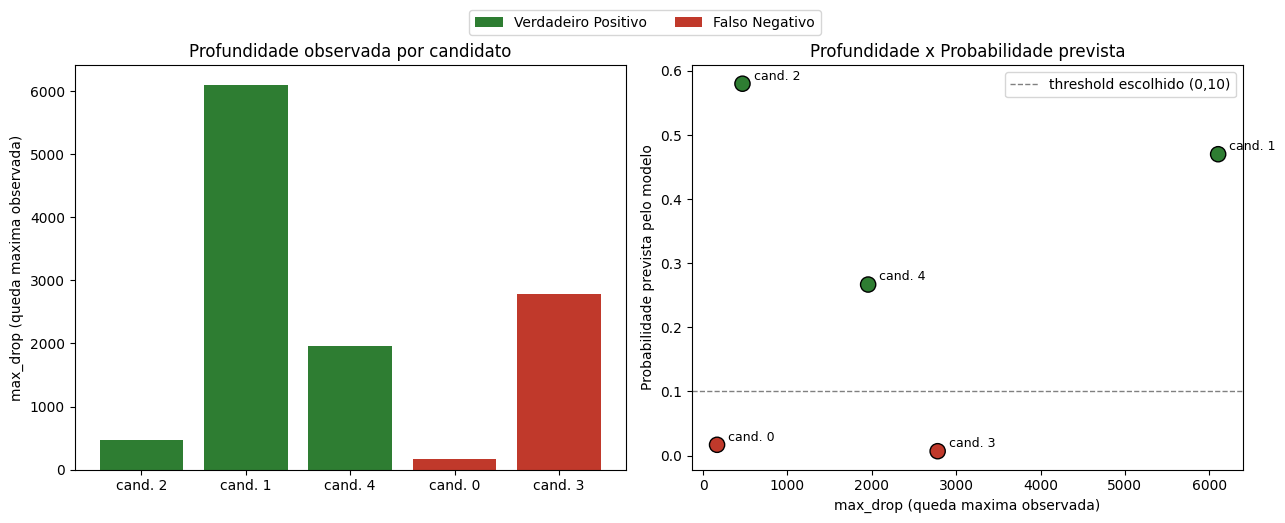

Repare no painel direito: o candidato 3 (Falso Negativo) tem profundidade (eixo X) maior que
dois dos Verdadeiros Positivos, mas ainda assim ficou com probabilidade baixa - confirmando
visualmente que 'profundidade absoluta' sozinha nao explica todos os erros do modelo.


In [ ]:
# Visualizacao dos 5 candidatos reais: profundidade relativa e probabilidade prevista,
# coloridos por grupo (Verdadeiro Positivo vs Falso Negativo)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cores_grupo = candidatos["grupo"].map({
    "Verdadeiro Positivo": "#2E7D32",
    "Falso Negativo": "#C0392B"
})

rotulos = [f"cand. {i}" for i in candidatos["indice"]]

axes[0].bar(rotulos, candidatos["max_drop"], color=cores_grupo)
axes[0].set_ylabel("max_drop (queda maxima observada)")
axes[0].set_title("Profundidade observada por candidato")
axes[0].tick_params(axis="x", rotation=0)

axes[1].scatter(candidatos["max_drop"], candidatos["probabilidade"],
                 c=cores_grupo, s=120, edgecolor="black", zorder=3)
for _, row in candidatos.iterrows():
    axes[1].annotate(f"cand. {row['indice']}", (row["max_drop"], row["probabilidade"]),
                      textcoords="offset points", xytext=(8, 3), fontsize=9)
axes[1].axhline(0.10, color="gray", ls="--", linewidth=1, label="threshold escolhido (0,10)")
axes[1].set_xlabel("max_drop (queda maxima observada)")
axes[1].set_ylabel("Probabilidade prevista pelo modelo")
axes[1].set_title("Profundidade x Probabilidade prevista")
axes[1].legend()

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor="#2E7D32", label="Verdadeiro Positivo"),
                Patch(facecolor="#C0392B", label="Falso Negativo")]
fig.legend(handles=legend_elems, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.savefig("candidatos_reais.png", dpi=110, bbox_inches="tight")
plt.show()

print("Repare no painel direito: o candidato 3 (Falso Negativo) tem profundidade (eixo X) maior que")
print("dois dos Verdadeiros Positivos, mas ainda assim ficou com probabilidade baixa - confirmando")
print("visualmente que 'profundidade absoluta' sozinha nao explica todos os erros do modelo.")

### Interpretação

Olhando só para `max_drop` (uma proxy de profundidade), seria tentador concluir uma história simples: "o modelo erra os trânsitos mais rasos". Mas os números reais são mais interessantes do que isso — e vale a pena mostrar essa nuance ao professor, porque é exatamente o tipo de raciocínio crítico que separa uma leitura superficial de uma análise cuidadosa:

- O candidato 3 (Falso Negativo) tem `max_drop` = 2.780,75 — maior que dois dos três Verdadeiros Positivos (candidatos 2 e 4). Ou seja, não é um trânsito raso em magnitude absoluta.
- O que diferencia o candidato 3 não é tão óbvio quanto duração: `duracao_media_25pct` = 4,27 pontos, ainda dentro da faixa dos outros — não é dramaticamente mais curto que os TP. O padrão real de por que ele escapou parece ser uma combinação de fatores, não um único culpado óbvio: o SHAP (Seção 11.2 do notebook de experimentos) aponta a `median` como o maior fator contra a classificação positiva do candidato 3 (SHAP = -0,21), o que sugere que, apesar da queda pontual profunda, ela afeta poucos pontos o suficiente para não deslocar a estatística de tendência central da curva como um todo — o "resumo estatístico" de 15 números simplesmente dilui um evento breve, mesmo que localmente intenso.
- Já o candidato 1 (o Verdadeiro Positivo com sinal mais robusto, `max_drop` = 6.105) tem tanto profundidade quanto número de eventos (65) consistentemente altos — um sinal mais "redundante" ao longo da curva, mais fácil de qualquer estatística agregada capturar.

**Conclusão física honesta:** a hipótese mais defensável, com os dados disponíveis, não é "trânsito raso = falso negativo", e sim algo mais preciso: trânsitos cuja assinatura fica estatisticamente diluída no resto da curva (seja por serem rasos, breves, ou ambos) são os que a Trilha A (features estatísticas agregadas + Random Forest) tem mais dificuldade de capturar — porque essas features, por construção, não sabem onde no tempo o evento aconteceu, só sabem que ele existe em algum lugar da distribuição de valores. Isso conecta diretamente com a limitação discutida na próxima seção.

## 9. O que a abordagem estatística não enxerga

As 15 features usadas neste projeto (Trilha A) tratam cada curva de luz como um saco de números — a ordem temporal dos 3.197 pontos é completamente descartada assim que calculamos mediana, quantis etc. Isso tem uma consequência importante: duas curvas com exatamente os mesmos 15 valores estatísticos, mas com o padrão de queda distribuído de forma completamente diferente ao longo do tempo, são indistinguíveis para o modelo.

Na prática, isso significa que o pipeline atual não consegue usar diretamente a informação mais característica de um trânsito real:

- **Periodicidade** — o fato de a queda se repetir em intervalos regulares (o que a Seção 2 explica vir diretamente da 3ª Lei de Kepler) é a assinatura mais confiável de um trânsito verdadeiro, e o principal jeito de distinguir um trânsito real de um evento único (como um trânsito de outra estrela contaminando o sinal, ou uma erupção estelar).
- **Forma do vale** (o perfil em U com ingresso/egresso suaves da Seção 3.4) — um trânsito real tem uma "assinatura" de formato específica; um ruído aleatório ou um artefato instrumental raramente produz esse formato.

É exatamente aqui que as outras trilhas do enunciado do trabalho fariam diferença:

- **Trilha D (RNN/LSTM)** processaria a curva como uma sequência de fato, podendo aprender padrões temporais como periodicidade e forma do vale diretamente dos dados brutos.
- **Trilha C (CNN 1D)**, embora tipicamente usada em imagens, também é aplicada com frequência a séries temporais de trânsitos (é, aliás, a abordagem usada em vários papers reais de classificação automática de curvas de luz do Kepler/TESS) — filtros convolucionais são naturalmente bons em detectar um "formato local" característico (o vale do trânsito) em qualquer posição da série.

Isso não invalida a escolha da Trilha A para este trabalho — ela é perfeitamente adequada ao escopo pedido (Aprendizado Supervisionado, Classificação) e ainda assim obteve um modelo funcional e explicável. Mas é uma limitação importante para mencionar na apresentação, mostrando consciência de que a escolha de representação dos dados tem um trade-off claro entre simplicidade/interpretabilidade (Trilha A) e capacidade de capturar a estrutura temporal completa do fenômeno físico (Trilhas C/D).

## 10. Glossário rápido

| Termo | Significado |
|---|---|
| **Trânsito** | Passagem de um planeta na frente do disco de sua estrela, do ponto de vista do observador, causando uma queda temporária no brilho observado. |
| **Curva de luz (light curve)** | Série temporal do brilho (fluxo) de uma estrela medido ao longo do tempo. |
| **Fluxo** | Medida de brilho — quantidade de luz recebida pelo instrumento por unidade de tempo. |
| **Profundidade do trânsito ($\delta$)** | Fração do brilho da estrela bloqueada durante o trânsito; $\delta = (R_p/R_\star)^2$. |
| **Período orbital ($P$)** | Tempo que o planeta leva para completar uma órbita completa; também o intervalo entre trânsitos consecutivos. |
| **Semieixo maior ($a$)** | Aproximadamente a distância média entre planeta e estrela. |
| **Parâmetro de impacto ($b$)** | Medida de quão centralizada é a passagem do planeta pelo disco estelar, vista da Terra. |
| **Escurecimento de limbo (limb darkening)** | Efeito pelo qual a borda do disco estelar aparece mais escura que o centro, suavizando o formato da curva de trânsito. |
| **Detrending** | Processo de remover tendências instrumentais de longo prazo de uma curva de luz, deixando só as variações de curto prazo (incluindo trânsitos). |
| **SNR (razão sinal-ruído)** | Medida de quão forte é um sinal em relação ao ruído de fundo; usada para decidir se um candidato a trânsito é estatisticamente confiável. |
| **Hot Jupiter** | Categoria de exoplaneta gigante gasoso (tamanho similar a Júpiter) em órbita muito próxima da estrela — tipicamente o tipo mais fácil de detectar pelo método de trânsito. |
| **Kepler (missão)** | Telescópio espacial da NASA (2009–2018) dedicado à busca de exoplanetas pelo método de trânsito; fonte dos dados usados neste projeto. |

---

### Referência rápida das fórmulas usadas neste notebook

$$ P^2 = \frac{4\pi^2}{G M_\star} a^3 \qquad\qquad \delta = \left(\frac{R_p}{R_\star}\right)^2 \qquad\qquad T_{14} \approx \frac{P}{\pi}\arcsin\left(\frac{R_\star}{a}\right) \qquad\qquad \text{SNR} = \delta\sqrt{N_{\text{trans}} N_{\text{pontos}}}\,/\,\sigma $$

---

## Menção honrosa: TRAPPIST-1 e o "Exoplanet Transit Explorer"

Antes de começar o ExoHunter-ML, o projeto que me inspirou a explorar detecção de exoplanetas foi o **"Exoplanet Transit Explorer"**, um MATLAB Live Script de D. Carlsmith (biblioteca de exemplos da MathWorks). Ele analisa dados reais de fotometria do telescópio espacial **Spitzer** sobre o sistema **TRAPPIST-1** — a anã ultrafria com sete planetas do tamanho da Terra, publicados por Gillon et al. (2017) na *Nature* [1].

Esse script faz, em MATLAB, exatamente o tipo de análise físico-matemática que motivou a Seção 3 deste notebook: ele localiza os trânsitos por processamento de sinal, "dobra" os sinais de cada planeta para reduzir ruído, e então usa a 3ª Lei de Kepler e a fórmula de profundidade de trânsito para calcular o raio orbital e o raio de cada um dos sete planetas — usando dados com calibração fotométrica absoluta (algo que, como vimos na Seção 4, o dataset do Kaggle usado no ExoHunter-ML não permite fazer diretamente).

Como forma de reconhecer essa inspiração, a célula abaixo aplica as mesmas duas fórmulas centrais deste notebook (3ª Lei de Kepler e profundidade de trânsito) aos **sete planetas reais do TRAPPIST-1**, usando parâmetros publicados (não são recalculados a partir dos dados brutos — são valores de catálogo, citados abaixo) só por curiosidade, para fechar o ciclo entre a inspiração original e o que foi construído aqui.

> **Fontes dos dados:** massa e raio da estrela conforme citados no script original (Gillon et al. 2017 [1]); período orbital, raio e massa de cada planeta segundo o catálogo de exoplanetas da NASA (`science.nasa.gov/exoplanet-catalog`) [2].

In [ ]:
# Parametros reais do sistema TRAPPIST-1 (dados de catalogo, nao recalculados aqui)

# Estrela (conforme citado no script original, a partir de Gillon et al. 2017)
M_estrela_msol = 0.089   # massas solares
R_estrela_rsol = 0.12    # raios solares

# Planetas: nome, periodo orbital (dias), raio (raios terrestres), massa (massas terrestres),
# semieixo maior publicado (AU) -- fonte: NASA Exoplanet Catalog
trappist1_planetas = pd.DataFrame([
    {"planeta": "b", "periodo_dias": 1.51087637,  "raio_terra": 1.116, "massa_terra": 1.374, "a_publicado_AU": 0.01154},
    {"planeta": "c", "periodo_dias": 2.42180746,  "raio_terra": 1.097, "massa_terra": 1.308, "a_publicado_AU": 0.01580},
    {"planeta": "d", "periodo_dias": 4.049959,    "raio_terra": 0.788, "massa_terra": 0.388, "a_publicado_AU": 0.02227},
    {"planeta": "e", "periodo_dias": 6.099043,    "raio_terra": 0.920, "massa_terra": 0.692, "a_publicado_AU": 0.02925},
    {"planeta": "f", "periodo_dias": 9.205585,    "raio_terra": 1.045, "massa_terra": 1.039, "a_publicado_AU": 0.03849},
    {"planeta": "g", "periodo_dias": 12.354473,   "raio_terra": 1.129, "massa_terra": 1.321, "a_publicado_AU": 0.04683},
    {"planeta": "h", "periodo_dias": 18.767953,   "raio_terra": 0.755, "massa_terra": 0.326, "a_publicado_AU": 0.06189},
])

R_terra_km = 6371
R_estrela_km = R_estrela_rsol * R_sol_km  # R_sol_km ja definido na Secao 3

# 1) Aplicando a 3a Lei de Kepler (mesma formula da Secao 2) para RECALCULAR
#    o semieixo maior a partir do periodo, usando a massa real da estrela
trappist1_planetas["periodo_anos"] = trappist1_planetas["periodo_dias"] / 365.25
trappist1_planetas["a_calculado_AU"] = (
    trappist1_planetas["periodo_anos"]**2 * M_estrela_msol
) ** (1/3)

# 2) Aplicando a formula de profundidade de transito (Secao 3.1) usando o raio
#    real de cada planeta e o raio real da estrela
trappist1_planetas["Rp_sobre_Restrela"] = (
    trappist1_planetas["raio_terra"] * R_terra_km / R_estrela_km
)
trappist1_planetas["profundidade_prevista_ppm"] = (
    trappist1_planetas["Rp_sobre_Restrela"]**2 * 1_000_000
).round(0)

print("Aplicando as formulas das Secoes 2 e 3 aos 7 planetas reais do TRAPPIST-1:\n")
display(trappist1_planetas[[
    "planeta", "periodo_dias", "a_publicado_AU", "a_calculado_AU",
    "raio_terra", "profundidade_prevista_ppm"
]].round(5))

erro_medio = (
    (trappist1_planetas["a_calculado_AU"] - trappist1_planetas["a_publicado_AU"]).abs()
    / trappist1_planetas["a_publicado_AU"]
).mean() * 100

Aplicando as formulas das Secoes 2 e 3 aos 7 planetas reais do TRAPPIST-1:



,planeta,periodo_dias,a_publicado_AU,a_calculado_AU,raio_terra,profundidade_prevista_ppm
0,b,1.51088,0.01154,0.01151,1.116,7240.0
1,c,2.42181,0.01580,0.01576,1.097,6996.0
2,d,4.04996,0.02227,0.02220,0.788,3610.0
3,e,6.09904,0.02925,0.02917,0.920,4920.0
4,f,9.20558,0.03849,0.03838,1.045,6348.0
5,g,12.35447,0.04683,0.04670,1.129,7410.0
6,h,18.76795,0.06189,0.06171,0.755,3314.0


O semieixo maior recalculado pela 3a Lei de Kepler bate com o valor publicado
com um erro medio de apenas 0.29% - a mesma formula usada na Secao 2
deste notebook, aplicada a um sistema planetario real.

Repare tambem que a profundidade de transito prevista para esses planetas fica na
faixa de milhares de ppm (muito maior que os ~84 ppm de um planeta tipo-Terra ao redor
do Sol, calculados na Secao 3) - o TRAPPIST-1 e uma anа muito menor que o Sol, entao
mesmo planetas do tamanho da Terra bloqueiam uma fracao bem maior da sua luz.

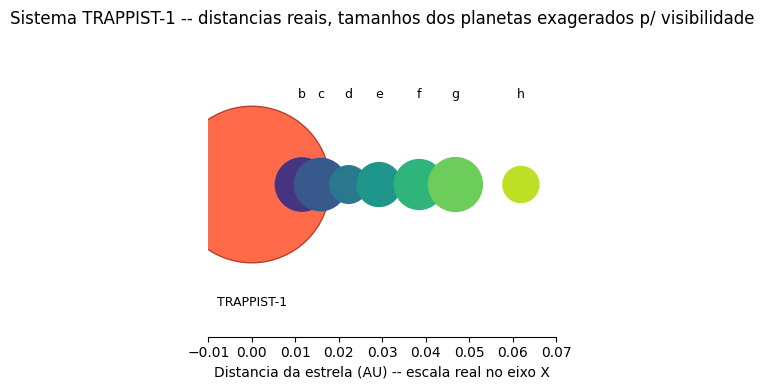

In [ ]:
# Retrato do sistema (em homenagem ao grafico "viscircles" do script original em MATLAB)

fig, ax = plt.subplots(figsize=(12, 4))

# estrela em x=0 (raio exagerado para visibilidade, ja que em escala real seria um ponto)
estrela_vis = plt.Circle((0, 0), R_estrela_rsol * 0.15, color="#FF6B4A", ec="#B8402A", zorder=2)
ax.add_patch(estrela_vis)
ax.text(0, -0.028, "TRAPPIST-1", ha="center", fontsize=9)

cores_planetas = plt.cm.viridis(np.linspace(0.15, 0.9, len(trappist1_planetas)))

for (_, row), cor in zip(trappist1_planetas.iterrows(), cores_planetas):
    raio_visual = (row["raio_terra"] * R_terra_km / R_sol_km) * 0.6  # exagerado p/ visibilidade
    circ = plt.Circle((row["a_publicado_AU"], 0), raio_visual, color=cor, zorder=3)
    ax.add_patch(circ)
    ax.text(row["a_publicado_AU"], 0.02, row["planeta"], ha="center", fontsize=9)

ax.set_xlim(-0.01, 0.07)
ax.set_ylim(-0.035, 0.035)
ax.set_aspect("equal")
ax.set_xlabel("Distancia da estrela (AU) -- escala real no eixo X")
ax.set_yticks([])
ax.set_title("Sistema TRAPPIST-1 -- distancias reais, tamanhos dos planetas exagerados p/ visibilidade")
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("trappist1_sistema.png", dpi=110, bbox_inches="tight")
plt.show()

As distancias no eixo X estao em escala real (AU). Os tamanhos dos planetas e da
estrela foram exagerados propositalmente - em escala real de tamanho, todos os
sete planetas seriam pontos invisiveis a essa distancia da tela.